# Interactive Segmentation with SAM3

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/segment-geospatial/blob/main/docs/examples/sam3_interactive.ipynb)

This notebook demonstrates how to segment remote sensing images interactively using the Segment Anything Model 3 (SAM3).

## Installation

First, make sure you have the required dependencies installed:

In [2]:
import sys
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

Python version: 3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]
Python executable: /media/gisense/xihan/geoai_sam/bin/python


In [3]:
%pip install "segment-geospatial[samgeo3]"

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install transformers==5.0.0rc0

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#%pip install git+https://github.com/huggingface/transformers.git

## Import Libraries


In [5]:
%pip install leafmap

Note: you may need to restart the kernel to use updated packages.


In [6]:
import leafmap
from samgeo import SamGeo3, download_file

In [7]:
# Add this diagnostic cell at the top of your notebook
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Check if samgeo is installed
try:
    import samgeo
    print(f"\n✅ samgeo location: {samgeo.__file__}")
    print(f"samgeo version: {samgeo.__version__}")
    print(f"Available in samgeo: {dir(samgeo)}")
except Exception as e:
    print(f"❌ Error: {e}")

# Try to check what's available
try:
    from samgeo import SamGeo3
    print("✅ SamGeo3 imported successfully")
except ImportError as e:
    print(f"❌ Cannot import SamGeo3: {e}")

Python executable: /media/gisense/xihan/geoai_sam/bin/python
Python version: 3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]

✅ samgeo location: /media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/__init__.py
samgeo version: 1.0.1
Available in samgeo: ['Any', 'Dict', 'Image', 'KMeans', 'List', 'MetaSam3Processor', 'Optional', 'SAM3_META_AVAILABLE', 'SAM3_TRANSFORMERS_AVAILABLE', 'Sam3Model', 'SamAutomaticMaskGenerator', 'SamGeo', 'SamGeo2', 'SamGeo3', 'SamGeo3Video', 'SamGeoPredictor', 'SamPredictor', 'TransformersSam3Processor', 'Tuple', 'Union', '__author__', '__builtins__', '__cached__', '__doc__', '__email__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'array_to_image', 'bbox_to_xy', 'blend_images', 'build_sam3_image_model', 'build_sam3_video_predictor', 'common', 'coords_to_xy', 'cv2', 'download_checkpoint', 'download_file', 'draw_box_on_image', 'draw_tile', 'generate_colors', 'geojson_t

## Download Sample Data

Let's download a sample satellite image covering the University of California, Berkeley, for testing:


In [8]:
url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley.tif"
image_path = download_file(url)

uc_berkeley.tif already exists. Skip downloading. Set overwrite=True to overwrite.


In [9]:
m = leafmap.Map()
m.add_raster(image_path, layer_name="Satellite image")
m

Map(center=[37.87135, -122.25784999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

## Request access to SAM3

To use SAM3, you need to request access by filling out this form on Hugging Face: https://huggingface.co/facebook/sam3

Once you have access, uncomment the following code block and run it.

In [10]:
from huggingface_hub import login
login()

## Initialize SAM3

When initializing SAM3, you can choose the backend from "meta", or "transformers".

In [11]:
sam3 = SamGeo3(
    backend="transformers", device=None, checkpoint_path=None, load_from_HF=True
)

Using cuda device and transformers backend


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !
The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !


## Set the image

You can set the image by either passing the image path or the image URL.

In [12]:
sam3.set_image(image_path)

## Generate masks with text prompt

In [13]:
sam3.generate_masks(prompt="building")

Found 42 objects.


In [14]:
sam3.save_masks("masks.tif")

Saved 42 mask(s) to masks.tif


## Show the results

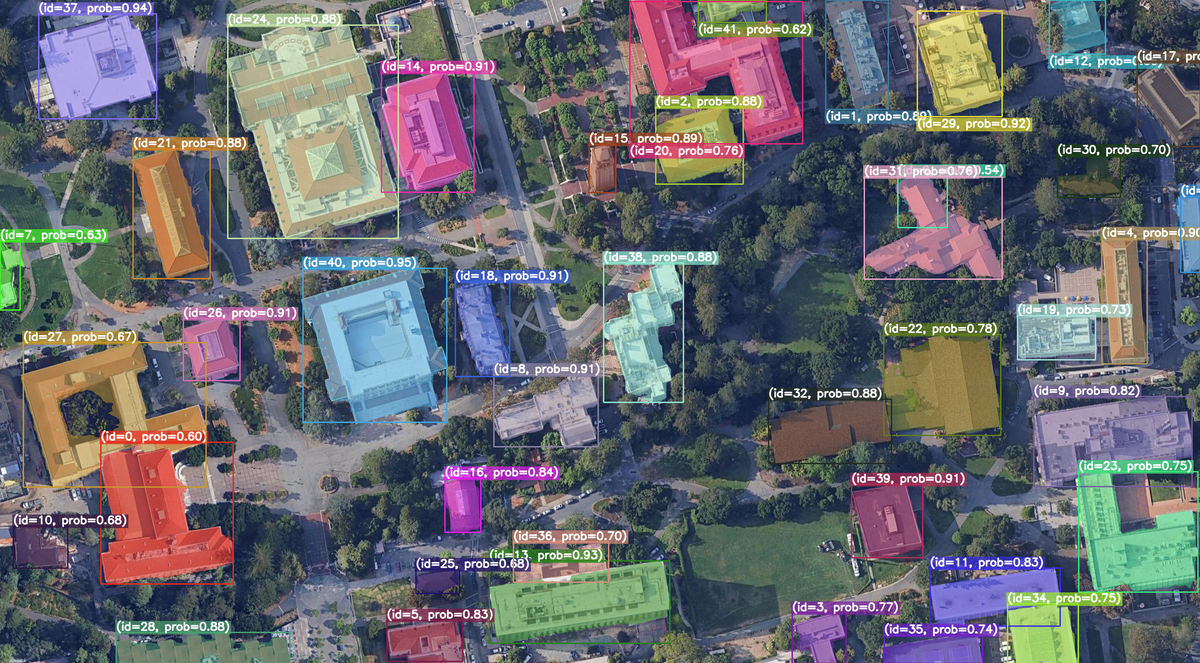

In [15]:
sam3.show_anns()

![annotation](https://github.com/user-attachments/assets/64323223-35a2-4e03-9cee-1b60fa0c12af)

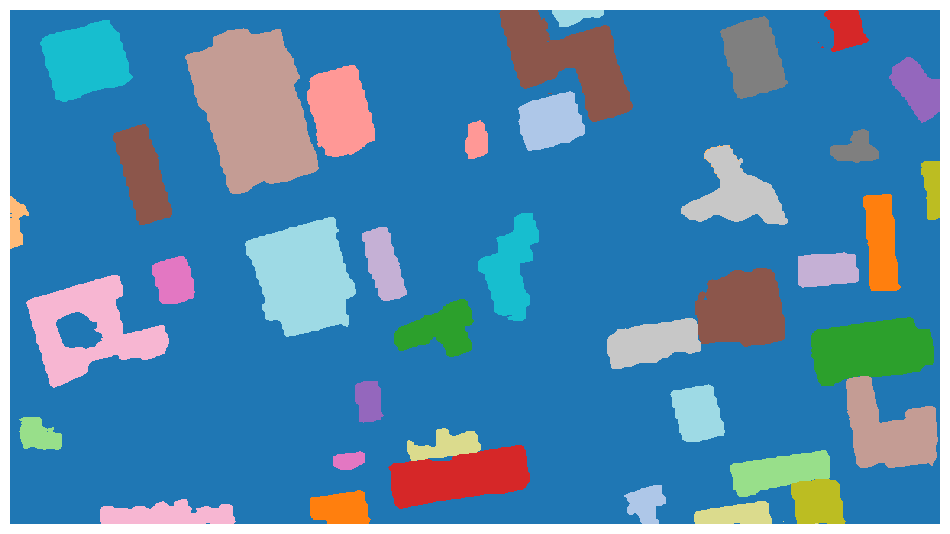

In [16]:
sam3.show_masks()

## Interactive segmentation

Enter a text prompt or draw a rectangle on the map, then click on the **Segment** button to perform instance segmentation.

In [17]:
sam3.show_map(height="700px", min_size=10)

Map(center=[37.87135, -122.25784999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

Segmentation by text prompts.

![image](https://github.com/user-attachments/assets/535d69b5-8e0f-46a3-8f8b-9fc602628a7f)

Segmentation by bounding boxes.

![](https://github.com/user-attachments/assets/3d6a5aed-8f3f-4350-ba26-04a84328c50d)